In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import joblib 

In [2]:
# load data

data=pd.read_csv('Crop_recommendation.csv')

data.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
data=data.drop(columns=["temperature","humidity","rainfall"])

data.head()

,N,P,K,ph,label
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [4]:
crop_counts = data['label'].value_counts()
print(crop_counts)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [5]:
# split data features

x=data.drop("label",axis=1)
y=data["label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
#model train Decision tree
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
#check model
y_pred = model.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

✅ Accuracy: 0.7636363636363637


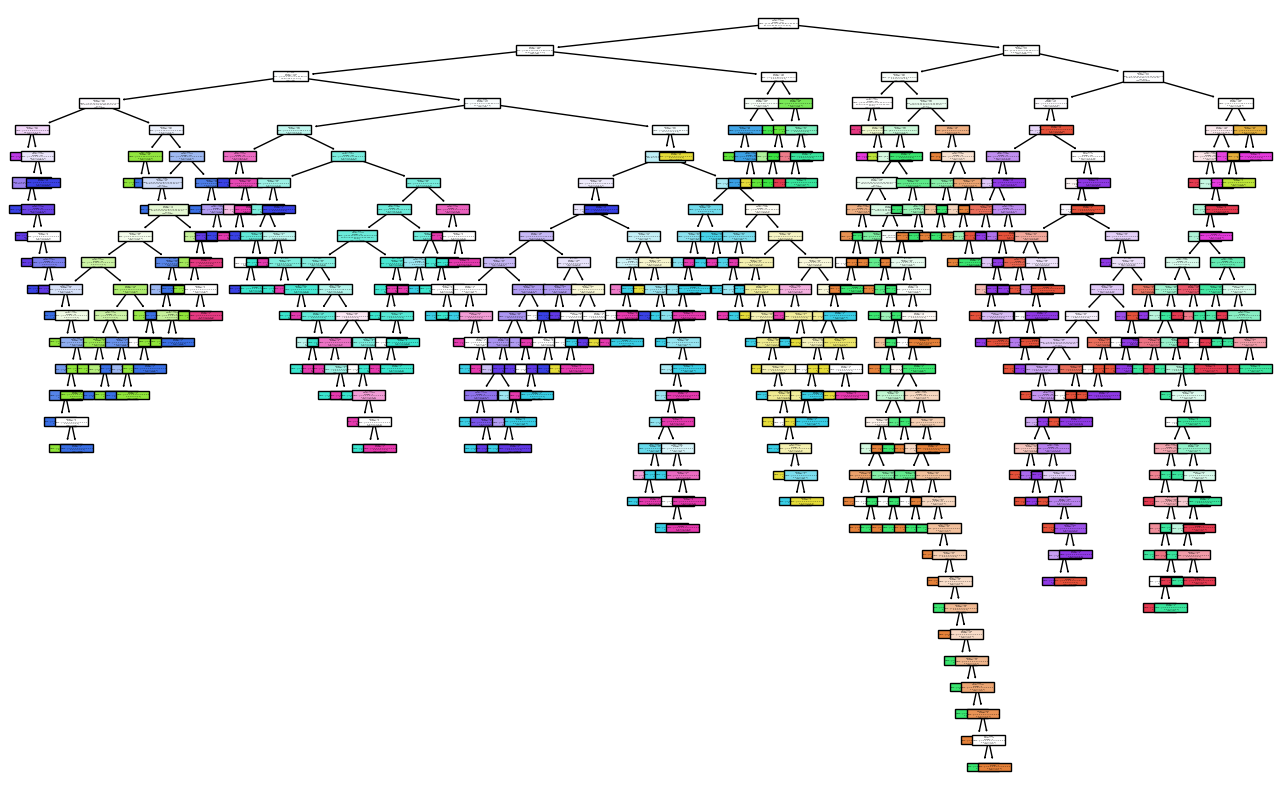

In [9]:
plt.figure(figsize=(16, 10))
plot_tree(model, feature_names=x.columns, class_names=model.classes_, filled=True)
plt.show()

In [10]:
sample=[[20,42,41,8.502985]]
prediction = model.predict(sample)
print("🌾 Recommended Crop:", prediction[0])

🌾 Recommended Crop: papaya


c:\khetmitra\model\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [11]:
# Save model
joblib.dump(model, "crop_model.pkl")
print("✅ Model saved as crop_model.pkl")

✅ Model saved as crop_model.pkl
